In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

current_features = list(X.columns)

rss_list = []
adj_r2_list = []
aic_list = []
bic_list = []
cv_error_list = []

feature_history = []

n = len(y)

In [2]:
while len(current_features) > 0:

    model = LinearRegression()
    model.fit(X[current_features], y)

    predictions = model.predict(X[current_features])

    rss = np.sum((y - predictions) ** 2)

    p = len(current_features)

    r2 = model.score(X[current_features], y)

    if p < n - 1:
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    else:
        adj_r2 = r2

    mse = rss / n

    aic = n * np.log(mse) + 2 * p
    bic = n * np.log(mse) + p * np.log(n)

    cv_scores = cross_val_score(
        LinearRegression(),
        X[current_features],
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_error = -cv_scores.mean()

    rss_list.append(rss)
    adj_r2_list.append(adj_r2)
    aic_list.append(aic)
    bic_list.append(bic)
    cv_error_list.append(cv_error)

    feature_history.append(current_features.copy())

    if len(current_features) == 1:
        break

    best_rss = np.inf
    feature_to_remove = None

    for feature in current_features:

        trial_features = current_features.copy()
        trial_features.remove(feature)

        trial_model = LinearRegression()
        trial_model.fit(X[trial_features], y)

        trial_predictions = trial_model.predict(X[trial_features])

        trial_rss = np.sum((y - trial_predictions) ** 2)

        if trial_rss < best_rss:
            best_rss = trial_rss
            feature_to_remove = feature

    print(f"Removed: {feature_to_remove}")

    current_features.remove(feature_to_remove)


Removed: Population
Removed: AveOccup
Removed: AveRooms
Removed: AveBedrms
Removed: HouseAge
Removed: Longitude
Removed: Latitude


In [3]:
print("\nModels Generated:")

for i, features in enumerate(feature_history):
    print(f"\nModel {i+1} ({len(features)} predictors)")
    print(features)


Models Generated:

Model 1 (8 predictors)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Model 2 (7 predictors)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']

Model 3 (6 predictors)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

Model 4 (5 predictors)
['MedInc', 'HouseAge', 'AveBedrms', 'Latitude', 'Longitude']

Model 5 (4 predictors)
['MedInc', 'HouseAge', 'Latitude', 'Longitude']

Model 6 (3 predictors)
['MedInc', 'Latitude', 'Longitude']

Model 7 (2 predictors)
['MedInc', 'Latitude']

Model 8 (1 predictors)
['MedInc']


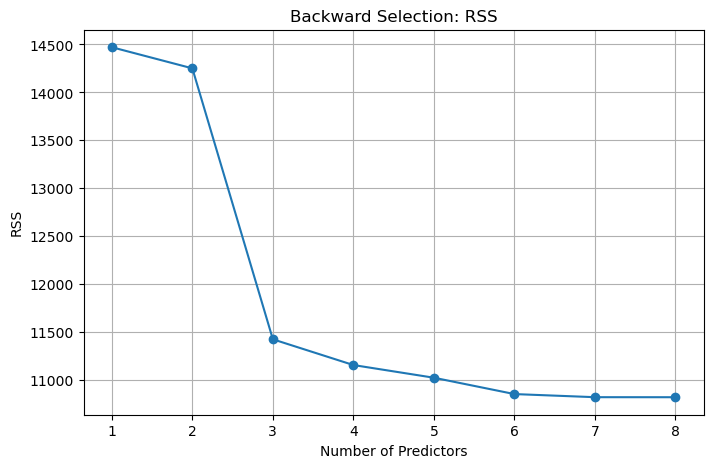

In [5]:
num_predictors = [len(f) for f in feature_history]
plt.figure(figsize=(8,5))
plt.plot(num_predictors, rss_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("Backward Selection: RSS")
plt.grid(True)
plt.show()